# Chapter 175 — Dimensionality Reduction

> **Prerequisites:** ch174 (PCA Intuition), ch173 (SVD), ch128 (Vector Length/Norm), ch131 (Dot Product)
> **You will learn:**
> - Why high-dimensional data is fundamentally different (curse of dimensionality)
> - PCA as the canonical linear dimensionality reduction method
> - Random projection as a fast, theoretically grounded alternative
> - Practical workflow: when to reduce, how much, and what to check
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

High-dimensional data has a fundamental problem: distances become meaningless. In 1000 dimensions, the nearest and farthest neighbors of a random point are almost equally far away. This is the **curse of dimensionality**.

Dimensionality reduction projects data from high-dimensional space to low-dimensional space while preserving as much structure as possible. The definition of "structure" determines the method:

- **Preserve variance:** PCA (ch174)
- **Preserve pairwise distances:** MDS (Multidimensional Scaling)
- **Preserve local neighborhoods:** t-SNE, UMAP (covered in Part IX)
- **Preserve random projections:** Johnson-Lindenstrauss lemma

This chapter consolidates PCA from ch174, introduces random projection, and establishes the practical workflow.

## 2. Intuition & Mental Models

**Curse of dimensionality:** In d dimensions, the volume of a hypercube with side 1 is 1, but a hypersphere inscribed in it has volume that shrinks exponentially with d. By d=100, essentially all the volume is in the corners, not the center. This makes nearest-neighbor search, density estimation, and clustering unreliable.

**Intrinsic dimensionality:** Most real datasets live on or near a low-dimensional manifold embedded in a high-dimensional space. A collection of face images is 10,000-dimensional (100×100 pixels), but the intrinsic degrees of freedom (lighting angle, pose, expression, identity) might be 10-20.

**Johnson-Lindenstrauss (JL) lemma:** A remarkable result — any n points in high-dimensional space can be projected to O(log n / ε²) dimensions using a random matrix while approximately preserving all pairwise distances (up to factor 1±ε). No structure in the data is exploited — it works for any dataset.

Recall from ch174: PCA is optimal for linear dimensionality reduction when the data is well-described by a linear subspace. JL projection is faster to compute and works without knowing the data's structure.

## 3. Visualization

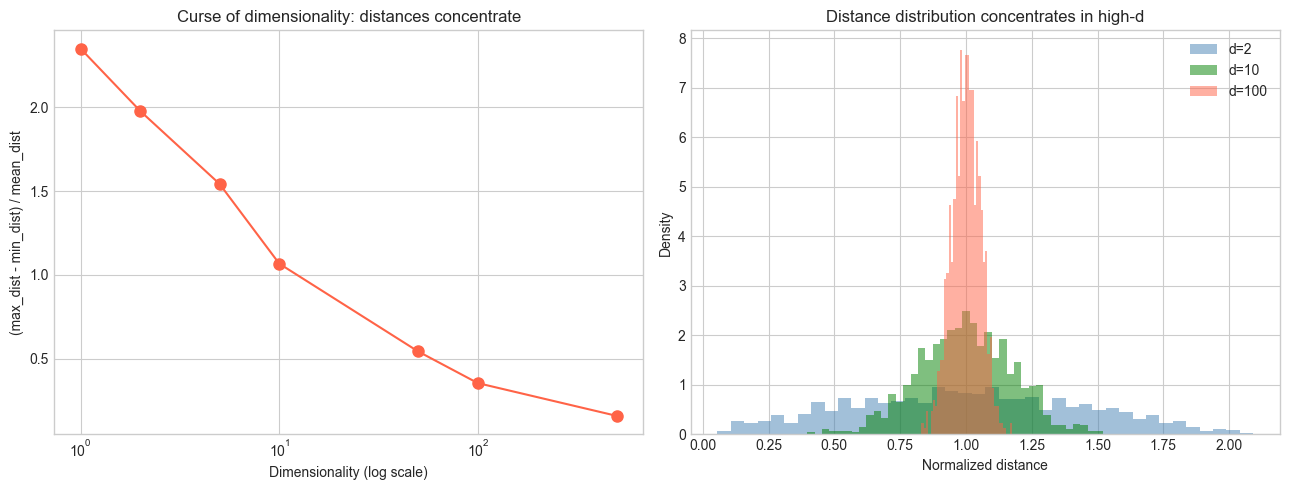

In [1]:
# --- Visualization: Curse of dimensionality ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

dims = [1, 2, 5, 10, 50, 100, 500]
N_SAMPLES = 1000
np.random.seed(42)

mean_ratios = []
for d in dims:
    # Random points in unit hypercube
    pts = np.random.rand(N_SAMPLES, d)
    ref = pts[0]
    dists = np.linalg.norm(pts[1:] - ref, axis=1)
    # Ratio of (max-min)/mean distance
    ratio = (dists.max() - dists.min()) / dists.mean()
    mean_ratios.append(ratio)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogx(dims, mean_ratios, 'o-', color='tomato', markersize=8)
axes[0].set_xlabel('Dimensionality (log scale)')
axes[0].set_ylabel('(max_dist - min_dist) / mean_dist')
axes[0].set_title('Curse of dimensionality: distances concentrate')

# Concentration of distance distributions
for d, color in zip([2, 10, 100], ['steelblue', 'green', 'tomato']):
    pts = np.random.rand(N_SAMPLES, d)
    dists = np.linalg.norm(pts[1:] - pts[0], axis=1)
    axes[1].hist(dists / dists.mean(), bins=40, alpha=0.5, density=True,
                 label=f'd={d}', color=color)
axes[1].set_xlabel('Normalized distance')
axes[1].set_ylabel('Density')
axes[1].set_title('Distance distribution concentrates in high-d')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**PCA projection (recap from ch174):**

    Z = (X - μ) · Vₖ    (n × k scores matrix)

Where Vₖ = first k columns of V from SVD of centered X.

**Johnson-Lindenstrauss lemma:** For any n points and ε ∈ (0, 1/2), a random projection matrix R ∈ ℝ^{k×d} with k ≥ 8 ln(n) / ε² and:

    R_ij ~ N(0, 1/k)

preserves all pairwise distances with high probability:

    (1-ε)||xᵢ - xⱼ||² ≤ ||Rxᵢ - Rxⱼ||² ≤ (1+ε)||xᵢ - xⱼ||²

**Variance captured vs dimensionality trade-off:**

The minimum k for PCA to capture fraction f of variance:

    k* = min{k : Σᵢ₌₁ᵏ σᵢ² / Σᵢ σᵢ² ≥ f}

## 5. Python Implementation

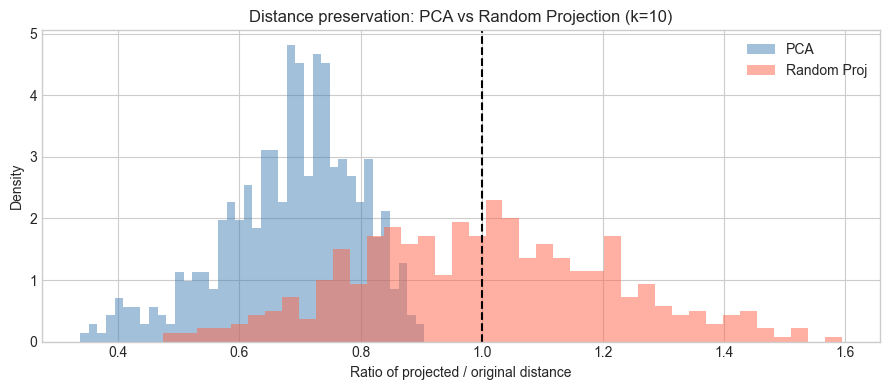

PCA: mean ratio = 0.684, std = 0.112
RP:  mean ratio = 1.003, std = 0.211


In [2]:
# --- Implementation: PCA and random projection, side-by-side ---
import numpy as np

def random_projection(X, k, seed=0):
    """
    Johnson-Lindenstrauss random projection to k dimensions.

    Projects X (n x d) down to (n x k) using Gaussian random matrix.
    Each entry R_ij ~ N(0, 1/k).

    Args:
        X: (n, d) data matrix
        k: target dimension

    Returns:
        Z: (n, k) projected data
        R: (k, d) projection matrix
    """
    np.random.seed(seed)
    d = X.shape[1]
    R = np.random.randn(k, d) / np.sqrt(k)
    return X @ R.T, R


def pca_project(X, k):
    """
    PCA projection to k dimensions.

    Args:
        X: (n, d) data matrix
        k: number of components

    Returns:
        Z: (n, k) scores
    """
    mean = X.mean(axis=0)
    _, _, Vt = np.linalg.svd(X - mean, full_matrices=False)
    return (X - mean) @ Vt[:k].T


def check_distance_preservation(X, Z, n_pairs=500, seed=1):
    """
    Check how well pairwise distances are preserved.

    Returns:
        ratio: Z distances / X distances for sampled pairs
    """
    np.random.seed(seed)
    n = X.shape[0]
    i_idx = np.random.randint(0, n, n_pairs)
    j_idx = np.random.randint(0, n, n_pairs)
    mask = i_idx != j_idx
    i_idx, j_idx = i_idx[mask], j_idx[mask]

    orig_dists = np.linalg.norm(X[i_idx] - X[j_idx], axis=1)
    proj_dists = np.linalg.norm(Z[i_idx] - Z[j_idx], axis=1)
    return proj_dists / orig_dists


# Compare on high-dimensional data
np.random.seed(42)
X_high = np.random.randn(200, 500) @ np.diag([5]*5 + [0.5]*495)  # first 5 dims matter
K = 10

Z_pca = pca_project(X_high, K)
Z_rp, _ = random_projection(X_high, K)

ratios_pca = check_distance_preservation(X_high, Z_pca)
ratios_rp = check_distance_preservation(X_high, Z_rp)

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(9, 4))
for ratios, label, color in [(ratios_pca, 'PCA', 'steelblue'),
                              (ratios_rp, 'Random Proj', 'tomato')]:
    plt.hist(ratios, bins=40, alpha=0.5, density=True, label=label, color=color)
plt.axvline(1.0, color='black', lw=1.5, ls='--')
plt.xlabel('Ratio of projected / original distance')
plt.ylabel('Density')
plt.title(f'Distance preservation: PCA vs Random Projection (k={K})')
plt.legend()
plt.tight_layout()
plt.show()
print(f"PCA: mean ratio = {ratios_pca.mean():.3f}, std = {ratios_pca.std():.3f}")
print(f"RP:  mean ratio = {ratios_rp.mean():.3f}, std = {ratios_rp.std():.3f}")

## 6. Experiments

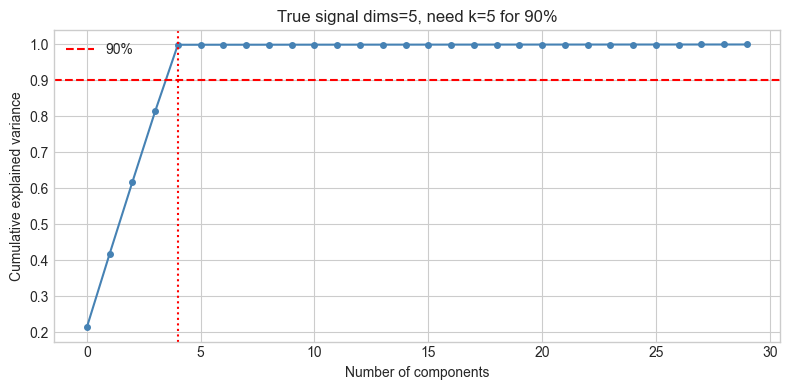

In [3]:
# --- Experiment 1: How many components needed for 90% variance? ---
# Hypothesis: Real-world-like structured data needs far fewer components than dimensions
# Try changing: N_SIGNAL_DIMS

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

N_SIGNAL_DIMS = 5   # try: 1, 5, 10, 20
N_TOTAL_DIMS = 100
np.random.seed(0)

# Signal + noise
signal_strength = np.concatenate([np.ones(N_SIGNAL_DIMS)*10,
                                   np.ones(N_TOTAL_DIMS - N_SIGNAL_DIMS)*0.1])
X = np.random.randn(500, N_TOTAL_DIMS) * signal_strength

_, s, _ = np.linalg.svd(X - X.mean(0), full_matrices=False)
cum_var = np.cumsum(s**2) / np.sum(s**2)

k90 = np.argmax(cum_var >= 0.9) + 1

plt.figure(figsize=(8, 4))
plt.plot(cum_var[:30], 'o-', color='steelblue', markersize=4)
plt.axhline(0.9, color='red', ls='--', label='90%')
plt.axvline(k90-1, color='red', ls=':')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title(f'True signal dims={N_SIGNAL_DIMS}, need k={k90} for 90%')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Exercises

**Easy 1.** Generate 1000 points uniform in a d-dimensional unit hypercube for d = 1, 2, 5, 10, 100. For each, compute the mean, min, and max pairwise distance. Plot them as a function of d. What happens to the ratio max/min?

**Easy 2.** The JL lemma says k ≥ 8 ln(n) / ε² suffices. For n=1000 points and ε=0.1, what is the minimum k? Verify empirically with `check_distance_preservation`.

**Medium 1.** Compare PCA and random projection on a synthetic dataset with 3 clusters in 50-dimensional space. Project to 2D with each method and plot the clusters. Which method better preserves cluster structure?

**Medium 2.** Implement `min_components_for_variance(X, threshold)` — returns the minimum number of PCA components needed to explain `threshold` fraction of variance. Apply it to datasets with different intrinsic dimensionalities.

**Hard.** The reconstruction error of PCA-k is ||X_c - X_c Vₖ Vₖᵀ||_F². Show algebraically that this equals Σᵢ₌ₖ₊₁ σᵢ² (using SVD). Then verify numerically. What does this tell you about the relationship between PCA reconstruction and the SVD approximation from ch173?

## 8. Mini Project: Comparing PCA and Random Projection on Text-Like Data

In [ ]:
# --- Mini Project: Nearest-neighbor search in reduced space ---
# Problem: High-dimensional similarity search is slow. Reduce dimensions
#          first, then compare search quality.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(5)

# Simulate bag-of-words style data: 500 documents, 200 terms
# 5 latent topics
N_DOCS = 500
N_TERMS = 200
N_TOPICS = 5

topics = np.abs(np.random.randn(N_TOPICS, N_TERMS))  # topic-term matrix
doc_topics = np.abs(np.random.randn(N_DOCS, N_TOPICS))  # doc-topic weights
X = doc_topics @ topics + 0.1 * np.abs(np.random.randn(N_DOCS, N_TERMS))

def nearest_neighbors(X, q_idx, k_nn=5):
    """
    Find k nearest neighbors of X[q_idx] in X.
    Returns sorted indices (excluding q_idx itself).
    """
    dists = np.linalg.norm(X - X[q_idx], axis=1)
    dists[q_idx] = np.inf
    return np.argsort(dists)[:k_nn]

# Ground truth neighbors in full space
K_NN = 10
query = 0
true_nn = set(nearest_neighbors(X, query, K_NN))

# Compare at different dimensionalities
K_VALUES = [2, 5, 10, 20, 50]
pca_recalls, rp_recalls = [], []

for k in K_VALUES:
    Z_pca = pca_project(X, k)
    Z_rp, _ = random_projection(X, k)

    pca_nn = set(nearest_neighbors(Z_pca, query, K_NN))
    rp_nn = set(nearest_neighbors(Z_rp, query, K_NN))

    pca_recalls.append(len(true_nn & pca_nn) / K_NN)
    rp_recalls.append(len(true_nn & rp_nn) / K_NN)

plt.figure(figsize=(8, 4))
plt.plot(K_VALUES, pca_recalls, 'o-', color='steelblue', label='PCA')
plt.plot(K_VALUES, rp_recalls, 's-', color='tomato', label='Random Projection')
plt.xlabel('Reduced dimension k')
plt.ylabel('Recall@10 (fraction of true NNs found)')
plt.title('Nearest-neighbor quality after dimensionality reduction')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Full dimension: {X.shape[1]}")
print(f"At k=10: PCA recall={pca_recalls[2]:.0%}, RP recall={rp_recalls[2]:.0%}")

## 9. Chapter Summary & Connections

- The curse of dimensionality: in high dimensions, distances concentrate and nearest-neighbor search becomes unreliable.
- PCA is the optimal linear dimensionality reduction for variance preservation; it requires computing the SVD of the data.
- Random projection (JL) preserves pairwise distances with high probability using a random Gaussian matrix — O(dk) to apply vs O(nd²) for PCA.
- Practical workflow: (1) scale features, (2) apply PCA, (3) choose k via scree plot or target variance, (4) validate downstream task quality.
- Both methods are linear — they cannot capture nonlinear manifold structure.

**Backward:** Consolidates ch174 (PCA) and ch173 (SVD) into a practical framework. The curse of dimensionality connects to ch129 (Distance in Vector Space).

**Forward:**
- ch176 (Matrix Calculus Introduction): gradients of matrix expressions — needed for training neural networks
- ch282 (Dimensionality Reduction — Part IX): t-SNE, UMAP, autoencoders as nonlinear alternatives
- ch187 (Face Recognition PCA): PCA at scale on image data

**Going deeper:** The Intrinsic Dimensionality Estimation problem (how many dimensions does a dataset truly need?) has no single answer — techniques like correlation dimension, MLE-based estimators, and two-NN estimator give different answers for different structures.